In [5]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet('_corrs.pq')
display(df)

,svid,cons,minute,s4A,s4B,elev_A,elev_B,azim_A,azim_B,r1loc,r2loc,corr_norm,lag_norm,max_corr,best_lag,time_delay
0,2,GAL,2022-10-04 22:22:00,0.248260,0.246203,32.000000,32.00000,306.131250,306.547917,"[-7.2121882, -35.90611, 0.55649865]","[-7.212652, -35.9073, 0.5425475]","[0.00023601625850355374, 0.0015509639844519247...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,6,0.30
1,2,GAL,2022-10-04 22:23:00,0.258300,0.282083,32.000000,32.00000,307.000000,307.000000,"[-7.2121882, -35.906105, 0.5563686]","[-7.212652, -35.907295, 0.542493]","[-1.7930009852308093e-05, -3.5860019704616186e...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,6,0.30
2,2,GAL,2022-10-04 22:24:00,0.356450,0.339789,31.639413,31.48847,307.360587,307.511530,"[-7.2121873, -35.906105, 0.55611974]","[-7.212652, -35.907295, 0.54223895]","[-0.0006721788745185038, -0.001344357749037007...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,6,0.30
3,2,GAL,2022-10-04 22:25:00,0.316135,0.314274,31.000000,31.00000,308.000000,308.000000,"[-7.2121873, -35.906105, 0.55578876]","[-7.212652, -35.907295, 0.5419835]","[4.9965221128560714e-05, 9.993044225712143e-05...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,6,0.30
4,2,GAL,2022-10-04 22:26:00,0.345028,0.325862,31.000000,31.00000,308.000000,308.481250,"[-7.2121882, -35.906105, 0.5553776]","[-7.212654, -35.907295, 0.5417687]","[-0.0001734960252106696, -0.000346992050421339...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,7,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,136,SBS,2022-10-04 23:37:00,0.332755,0.340081,42.000000,42.00000,82.000000,82.000000,"[-7.2122126, -35.906174, 0.55261135]","[-7.2126813, -35.907364, 0.53728354]","[-0.0002986801244202465, -0.000597360248840493...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,18,0.90
1531,136,SBS,2022-10-04 23:38:00,0.311478,0.274253,42.000000,42.00000,82.000000,82.000000,"[-7.2122173, -35.906174, 0.5526083]","[-7.2126837, -35.907364, 0.5371062]","[-0.001273931181367274, -0.002547862362734548,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,18,0.90
1532,136,SBS,2022-10-04 23:39:00,0.263936,0.258914,42.000000,42.00000,82.000000,82.000000,"[-7.2122197, -35.906174, 0.55342394]","[-7.2126837, -35.907364, 0.53767467]","[-0.000405569010462156, -0.000811138020924312,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,16,0.80
1533,136,SBS,2022-10-04 23:40:00,0.212937,0.179114,42.000000,42.00000,82.000000,82.000000,"[-7.2122235, -35.906166, 0.55444056]","[-7.2126865, -35.90736, 0.5384905]","[-0.0017825553229625494, -0.003565110645925099...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,23,1.15


In [6]:
#calculate distance using new df 

#method 2 calculating distance
#haversine formula : computes great circle distance follows earths curvature

#works for 1 row of r1loc and r2loc make it work for entire column
def haversine(lon1, lat1, lon2, lat2):
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)
    R = 6371 #km


    lamba = lon2 - lon1
    deta = lat2 - lat1

    a = (np.sin(deta/2))**2 + np.cos(lat1)*np.cos(lat2)*(np.sin(lamba/2))**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    d = R * c
    
    return(d)

def calc_dist(rloc1, rloc2):
    lat1, lon1, hei1 = rloc1
    lat2, lon2, hei2 = rloc2

    distances_2d = haversine(lon1, lat1, lon2, lat2)
    heights = (hei2 - hei1)

    distance = np.sqrt(distances_2d**2 + heights**2)
    #print(f'{distance} km')
    return distance

df['distance (km)'] = df.apply(lambda row: calc_dist(row['r1loc'], row['r2loc']), axis = 1)

#3D distance now using pythagorean theorem and curvature haversine distance


display(df)






,svid,cons,minute,s4A,s4B,elev_A,elev_B,azim_A,azim_B,r1loc,r2loc,corr_norm,lag_norm,max_corr,best_lag,time_delay,distance (km)
0,2,GAL,2022-10-04 22:22:00,0.248260,0.246203,32.000000,32.00000,306.131250,306.547917,"[-7.2121882, -35.90611, 0.55649865]","[-7.212652, -35.9073, 0.5425475]","[0.00023601625850355374, 0.0015509639844519247...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.724705,6,0.30,0.141599
1,2,GAL,2022-10-04 22:23:00,0.258300,0.282083,32.000000,32.00000,307.000000,307.000000,"[-7.2121882, -35.906105, 0.5563686]","[-7.212652, -35.907295, 0.542493]","[-1.7930009852308093e-05, -3.5860019704616186e...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.645983,6,0.30,0.141591
2,2,GAL,2022-10-04 22:24:00,0.356450,0.339789,31.639413,31.48847,307.360587,307.511530,"[-7.2121873, -35.906105, 0.55611974]","[-7.212652, -35.907295, 0.54223895]","[-0.0006721788745185038, -0.001344357749037007...","[-476, -475, -474, -473, -472, -471, -470, -46...",0.811655,6,0.30,0.141626
3,2,GAL,2022-10-04 22:25:00,0.316135,0.314274,31.000000,31.00000,308.000000,308.000000,"[-7.2121873, -35.906105, 0.55578876]","[-7.212652, -35.907295, 0.5419835]","[4.9965221128560714e-05, 9.993044225712143e-05...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.744665,6,0.30,0.141619
4,2,GAL,2022-10-04 22:26:00,0.345028,0.325862,31.000000,31.00000,308.000000,308.481250,"[-7.2121882, -35.906105, 0.5553776]","[-7.212654, -35.907295, 0.5417687]","[-0.0001734960252106696, -0.000346992050421339...","[-479, -478, -477, -476, -475, -474, -473, -47...",0.686357,7,0.35,0.141635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,136,SBS,2022-10-04 23:37:00,0.332755,0.340081,42.000000,42.00000,82.000000,82.000000,"[-7.2122126, -35.906174, 0.55261135]","[-7.2126813, -35.907364, 0.53728354]","[-0.0002986801244202465, -0.000597360248840493...","[-949, -948, -947, -946, -945, -944, -943, -94...",0.862867,18,0.90,0.141914
1531,136,SBS,2022-10-04 23:38:00,0.311478,0.274253,42.000000,42.00000,82.000000,82.000000,"[-7.2122173, -35.906174, 0.5526083]","[-7.2126837, -35.907364, 0.5371062]","[-0.001273931181367274, -0.002547862362734548,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.798184,18,0.90,0.141864
1532,136,SBS,2022-10-04 23:39:00,0.263936,0.258914,42.000000,42.00000,82.000000,82.000000,"[-7.2122197, -35.906174, 0.55342394]","[-7.2126837, -35.907364, 0.53767467]","[-0.000405569010462156, -0.000811138020924312,...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.765527,16,0.80,0.141787
1533,136,SBS,2022-10-04 23:40:00,0.212937,0.179114,42.000000,42.00000,82.000000,82.000000,"[-7.2122235, -35.906166, 0.55444056]","[-7.2126865, -35.90736, 0.5384905]","[-0.0017825553229625494, -0.003565110645925099...","[-959, -958, -957, -956, -955, -954, -953, -95...",0.589147,23,1.15,0.142438


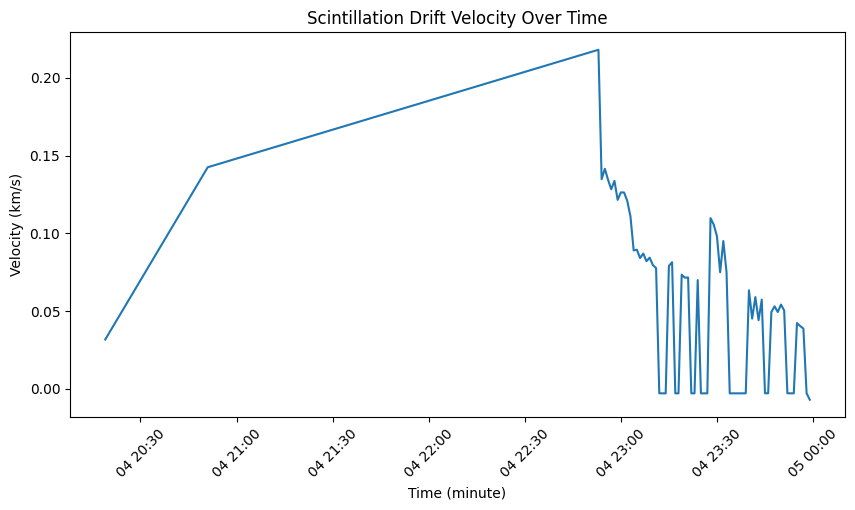

In [15]:
#find velocity

df['velocity (km/s)'] = df['distance (km)']/df['time_delay']
#print(f'{V} km/s')
#display(df)

df_sat = df[df['svid'] == 10] #& (df['cons'] == 3)

plt.figure(figsize=(10,5))
plt.plot(df_sat['minute'], df_sat['velocity (km/s)'])

plt.xlabel("Time (minute)")
plt.ylabel("Velocity (km/s)")
plt.title("Scintillation Drift Velocity Over Time")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#plotting
#sat should be in config
sat = df[(df['svid'] == 10) & (df['cons'] == 0)]

event = sat.iloc[10]

print(sat['max_corr'].iloc[10])
print(sat['best_lag'].iloc[10])
print(sat['time_delay'].iloc[10])

plt.plot(event['lag_norm'], event['corr_norm'])
plt.xlabel('lag')
plt.ylabel('correlation (normalized)')
plt.title('Normalized Cross Correlation')
plt.show()


IndexError: single positional indexer is out-of-bounds